# Day 2—Lining up the witnesses
*Measuring Manuscripts*

A text that survives in several copies is never copied perfectly, and the differences are evidence. CollateX lines the copies up, position by position, so you can see where they agree and where they diverge. Then you'll group the copies into a family tree, the way biologists group species by shared mutations.

## 1. Setup (run once)

In [1]:
!pip install collatex --quiet
!pip install Levenshtein --quiet   # lets CollateX match near-identical spellings

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.3/92.3 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.7 MB/s eta 0:00:00


In [2]:
from collatex import Collation, collate

## 2. A first collation

Three short witnesses of one sentence. Run it and read the table: each column is a position in the text, each row a witness, and a blank means that witness lacks a word there.

In [3]:
c = Collation()
c.add_plain_witness('A', 'The quick brown fox jumps over the lazy dog')
c.add_plain_witness('B', 'The quick red fox jumps over the dog')
c.add_plain_witness('C', 'The quick brown fox leaps over the lazy dog')

print(collate(c, output='table', segmentation=False))

+---+-----+-------+-------+-----+-------+------+-----+------+-----+
| A | The | quick | brown | fox | jumps | over | the | lazy | dog |
| B | The | quick | red   | fox | jumps | over | the | -    | dog |
| C | The | quick | brown | fox | leaps | over | the | lazy | dog |
+---+-----+-------+-------+-----+-------+------+-----+------+-----+


## 3. Reading the table

Read down each column. Where every row agrees, the text is stable; where they differ—*brown* vs *red*, *jumps* vs *leaps*, the missing *lazy*—you've found a variant. That's the unit textual criticism works on.

- Which two witnesses agree most often?
- Which column would you, as editor, have to rule on?

## 4. Other ways to see it

The table is one view. CollateX can also return the alignment as data (JSON) or draw a **variant graph**, a diagram of where the text splits and rejoins.

In [4]:
import json
result = collate(c, output='json', segmentation=False)
parsed = json.loads(result) if isinstance(result, str) else result
print('Columns in the alignment:', len(parsed['table'][0]))

Columns in the alignment: 9


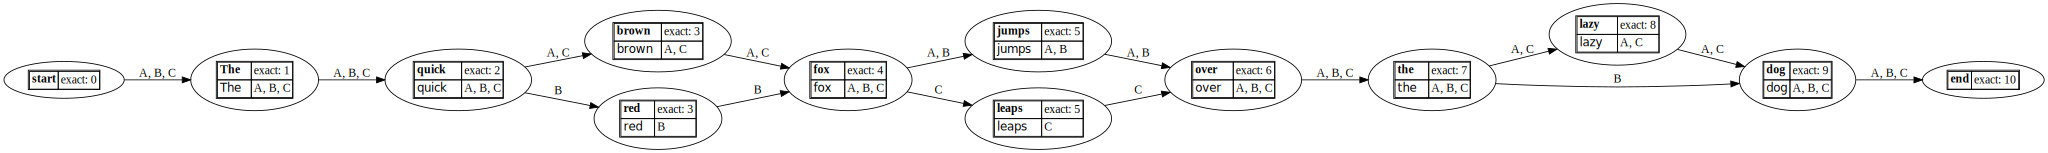

<IPython.core.display.SVG object>

Variant graph skipped ( NameError ). Install graphviz to enable it.


In [11]:
# The variant graph needs graphviz. If this errors, it just means graphviz isn't installed —
# the rest of the notebook is unaffected.
try:
    svg = collate(c, output='svg', segmentation=False)
    from IPython.display import SVG, display
    display(SVG(svg))
except Exception as e:
    print('Variant graph skipped (', type(e).__name__, '). Install graphviz to enable it.')

## 5. Catching spelling variants

Scribes spell loosely. *colour* and *color* are the same word, but a strict match treats them as a variant. With near-matching enabled (the reason for the Levenshtein install), CollateX lines up words that are merely close.

In [6]:
c2 = Collation()
c2.add_plain_witness('A', 'a knight ther was and a worthy man')
c2.add_plain_witness('B', 'a knyght ther was and a worthi man')

print('Strict:')
print(collate(c2, output='table', segmentation=False))
print('\nNear-match (knight/knyght, worthy/worthi line up):')
print(collate(c2, output='table', segmentation=False, near_match=True))

Strict:
+---+---+--------+------+-----+-----+---+--------+-----+
| A | a | knight | ther | was | and | a | worthy | man |
| B | a | knyght | ther | was | and | a | worthi | man |
+---+---+--------+------+-----+-----+---+--------+-----+

Near-match (knight/knyght, worthy/worthi line up):
+---+---+--------+------+-----+-----+---+--------+-----+
| A | a | knight | ther | was | and | a | worthy | man |
| B | a | knyght | ther | was | and | a | worthi | man |
+---+---+--------+------+-----+-----+---+--------+-----+


## 6. The four witnesses (yesterday's puzzle)

These are the four copies from the end of Day 1—the couplet whose true reading survives in *none* of them. They now live in the repo as four small text files, and we fetch them straight from GitHub (the same way we loaded the full text yesterday) and let CollateX line them up.

In [ ]:
import urllib.request

base = ('https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/'
        'refs/heads/main/Workbook/Day%202%E2%80%94Textual%20Criticism/witnesses/')
files = {'Witness 1': 'w1.txt', 'Witness 2': 'w2.txt',
         'Witness 3': 'w3.txt', 'Witness 4': 'w4.txt'}

witnesses = {}
for name, fn in files.items():
    witnesses[name] = urllib.request.urlopen(base + fn).read().decode('utf-8').strip()

real = Collation()
for name, txt in witnesses.items():
    real.add_plain_witness(name, txt)

print(collate(real, output='table', segmentation=False, near_match=True))

## 7. From variants to a family tree

Here is the day's central idea. Texts mutate as they're copied, much as DNA mutates as it replicates, so the biologist's tools transfer. Measure how different each pair of witnesses is, then build a tree that groups the closest ones.

Below, the distance between two witnesses is how much editing turns one into the other. The dendrogram clusters them.

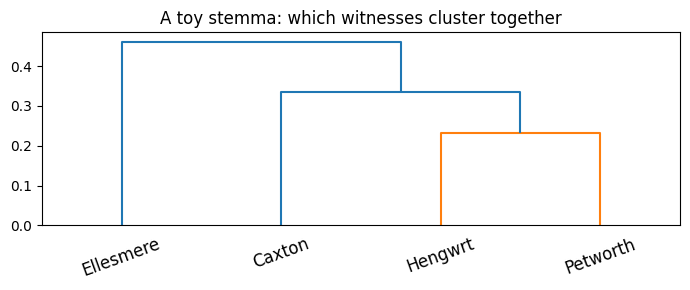

In [8]:
import numpy as np, difflib
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

names = list(witnesses)
texts = [witnesses[n].lower().split() for n in names]
n = len(names)
D = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        D[i, j] = 1 - difflib.SequenceMatcher(None, texts[i], texts[j]).ratio()

Z = linkage(squareform(D, checks=False), method='average')
plt.figure(figsize=(7, 3))
dendrogram(Z, labels=names, leaf_rotation=20)
plt.title('A toy stemma: which witnesses cluster together'); plt.tight_layout(); plt.show()

With real witnesses, a tree like this is a first hypothesis about how the manuscripts are related—which copy descends from which. It's only a hypothesis. Two scribes can make the same easy error independently, and the tree can't tell that apart from shared descent.

## 8. Recovering the reading no witness preserves

This is the payoff of yesterday's puzzle. The alignment makes the situation undeniable: line A ends on a different word in every witness, while line B's rhyme word holds steady. Pull the two columns out and look.

In [ ]:
# Line A (13) ends differently in every witness; line B (14), the rhyme, is stable.
print(f"{'witness':12} {'line A ends':12} {'line B ends'}")
for name, txt in witnesses.items():
    rows  = txt.splitlines()
    cruxA = rows[2].split('straunge ')[1].rstrip(',')
    rhymeB = rows[3].rstrip(';').split()[-1]
    print(f'{name:12} {cruxA:12} {rhymeB}')

Now the reasoning. Every witness ends line B with **londes**, so line A has to rhyme with it. None of *shores*, *costes*, *contrees* does, and Witness 3's *londes* only "rhymes" by repeating the word from the line below—an eye-skip, not a reading. Yet all four agree on **meaning**: shore, coast, far country across the sea. So Chaucer's word meant *shores*, rhymed with *londes*, and was rarer than any of the four substitutes—rare enough that each scribe replaced it with something more familiar.

That word is **strondes**. Chaucer wrote:

> And palmeres for to seken straunge **strondes**, / To ferne halwes, kowthe in sondry **londes**;

—and not one of the four copies kept it. Notice what the computer did and didn't do. It didn't conjure *strondes* out of nothing; it can only show you readings that are in the witnesses. What it did was line the copies up so the gap was impossible to miss, and make that same reasoning survivable across eighty witnesses instead of four. The conjecture is still yours. The bookkeeping is the machine's.

## 9. Your turn

Add a fifth witness to the dictionary in section 6 (invent a plausible spelling), re-run sections 6 and 7, and see where it lands on the tree. Did it go where you expected?

### Read the result
- Which two witnesses came out closest? Does that match what you saw in the table?
- Choose one variant. Which reading would you adopt as editor, and why?
- What does the alignment not tell you—where do you still need a human?